In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [2]:
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)


In [3]:
class Config:
  seed : int = 42
  batch_size : int = 100
  learning_rate : float = 0.001
  epochs : int = 10

  # 조작 변인
  two_conv : bool = True # True or False
  dropout : bool = False # False or True
  dropout_p : float = 0.5
  optimizer : str = "sgd"  # adam or sgd

  device : str = "cuda" if torch.cuda.is_available() else "cpu"

# Conv2d (1,32,kernel=3, s=1, p=1)
# ReLU
# MaxPool2d(2,2)
# Conv2d(32, 64, kernel = 3, s=1, p=1)
# ReLU
# MaxPool2d(2,2)
# Flatten
# Linear (64*7*7, 128)
# ReLU
# Linear (128,10)

# Loss : CrossEntropy

In [4]:
def get_dataloaders(config:Config):
  transform = transforms.ToTensor()

  full_train_dataset = datasets.MNIST(
      root = "./data",
      train = True,
      download = True,
      transform = transform
  )

  full_test_dataset = datasets.MNIST(
      root = "./data",
      train = False,
      download = True,
      transform = transform
  )


  train_dataset, val_dataset,_ = random_split(
      full_train_dataset, [5000,1000,54000] ,
      generator = torch.Generator().manual_seed(config.seed))


  test_dataset,_ = random_split(
      full_test_dataset,[1000,9000],
      generator = torch.Generator().manual_seed(config.seed)
  )



  train_loader = DataLoader(
      train_dataset,
      batch_size = config.batch_size,
      shuffle = True
  )

  val_loader = DataLoader(
      val_dataset,
      batch_size = config.batch_size,
      shuffle = False
  )

  test_loader = DataLoader(
      test_dataset,
      batch_size = config.batch_size,
      shuffle = False
  )

  return train_loader, val_loader, test_loader

In [5]:
class SimpleCNN(nn.Module):
  def __init__(self, two_conv=True, dropout=False, dropout_p=0.5):
    super().__init__()

    self.two_conv = two_conv
    self.dropout = dropout

    if two_conv :
      self.features = nn.Sequential (
          nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2),

          nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2)
        )
      fc_input_dim = 64*7*7

    else :
      self.features = nn.Sequential (
          nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2)
        )
      fc_input_dim = 32*14*14


    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(fc_input_dim, 128),
        nn.ReLU(),
        nn.Dropout(dropout_p) if dropout else nn.Identity(),
        nn.Linear(128,10)
    )

  def forward (self,x):
    x = self.features(x)
    x = self.classifier(x)
    return x


In [6]:
def get_optimizer(model,config:Config):
  if config.optimizer == "adam":
    return optim.Adam(model.parameters(), lr = config.learning_rate)
  elif config.optimizer == "sgd":
    return optim.SGD(model.parameters(), lr = config.learning_rate)
  else:
    raise ValueError ("OPTIMIZER must be 'adam' or 'sgd' ")

In [7]:
def accuracy(outputs, labels):
  preds = torch.argmax(outputs, dim=1)
  correct = (preds == labels).sum().item()
  return correct / labels.size(0)

In [8]:
def train_one_epoch ( model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  running_correct = 0
  total = 0

  for images, labels in loader :
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model (images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    preds = torch.argmax(outputs, dim=1)
    running_correct += (preds == labels).sum().item()
    total += images.size(0)

  epoch_loss = running_loss / total
  epoch_acc = running_correct / total
  return epoch_loss, epoch_acc




In [9]:
def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  running_correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in loader :
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * images.size(0)
      preds = torch.argmax(outputs, dim=1)
      running_correct += (preds == labels).sum().item()
      total += images.size(0)

  epoch_loss = running_loss / total
  epoch_acc = running_correct / total
  return epoch_loss, epoch_acc


In [10]:


def run_experiment(config : Config):
  set_seed(config.seed)
  device = config.device

  train_loader, val_loader, test_loader = get_dataloaders(config)

  model = SimpleCNN(two_conv=config.two_conv, dropout=config.dropout).to(device)


  criterion = nn.CrossEntropyLoss()
  optimizer = get_optimizer(model, config)

  train_loss_list = []
  train_acc_list = []
  val_loss_list = []
  val_acc_list = []

  print (f"CNN : two_conv = {config.two_conv}, dropout = {config.dropout},  optimizer = {config.optimizer}")

  for epoch in range(config.epochs):
    train_loss,train_acc = train_one_epoch(model,train_loader,criterion,optimizer,device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{config.epochs}",end=" ")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")


  test_loss, test_acc = evaluate(model, test_loader, criterion, device)
  print(f"Test acc : {test_acc*100:.2f}%")



  return train_loss_list, val_acc_list



In [11]:
config = Config()
train_loss, val_acc = run_experiment(config)

CNN : two_conv = True, dropout = False,  optimizer = sgd
Epoch  1/10 Train Loss: 2.3003 | Train Acc: 16.28% | Val Acc: 17.90%
Epoch  2/10 Train Loss: 2.2986 | Train Acc: 19.00% | Val Acc: 19.30%
Epoch  3/10 Train Loss: 2.2970 | Train Acc: 19.80% | Val Acc: 19.20%
Epoch  4/10 Train Loss: 2.2955 | Train Acc: 19.28% | Val Acc: 18.90%
Epoch  5/10 Train Loss: 2.2940 | Train Acc: 19.62% | Val Acc: 19.00%
Epoch  6/10 Train Loss: 2.2925 | Train Acc: 19.66% | Val Acc: 19.60%
Epoch  7/10 Train Loss: 2.2911 | Train Acc: 20.14% | Val Acc: 20.20%
Epoch  8/10 Train Loss: 2.2896 | Train Acc: 21.26% | Val Acc: 20.30%
Epoch  9/10 Train Loss: 2.2881 | Train Acc: 21.00% | Val Acc: 20.60%
Epoch 10/10 Train Loss: 2.2865 | Train Acc: 21.62% | Val Acc: 21.00%
Test acc : 21.30%


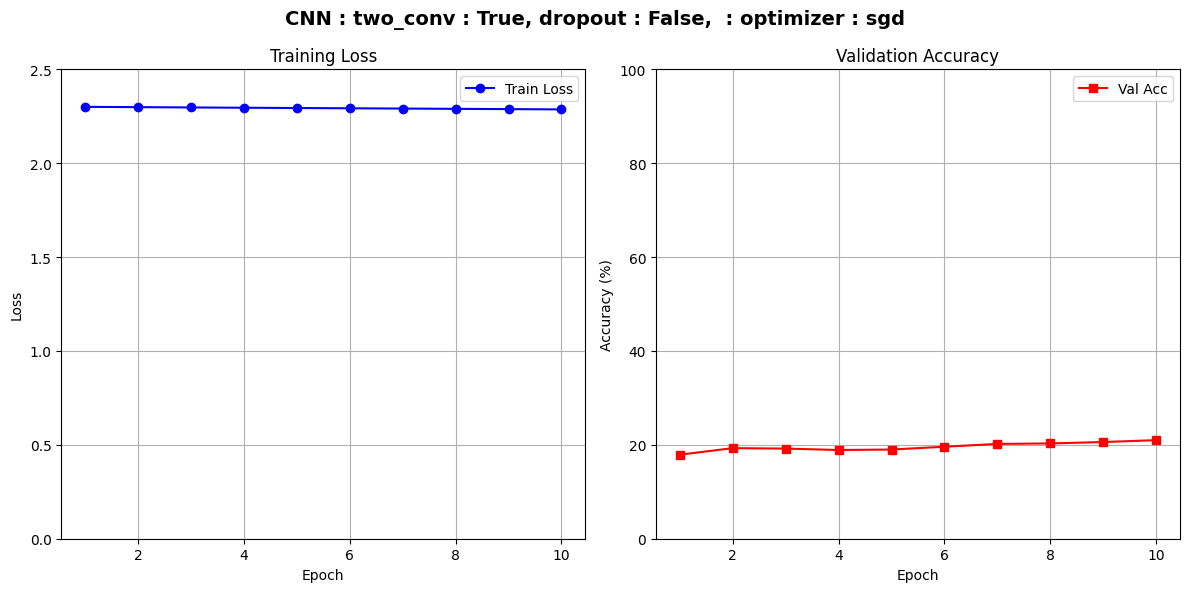

In [12]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.suptitle(f"CNN : two_conv : {config.two_conv}, dropout : {config.dropout},  : optimizer : {config.optimizer}",
             fontsize=14, fontweight='bold', y=0.98)


# --- 왼쪽: Training Loss (스케일 0 ~ 2.5 고정!) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, config.epochs + 1), train_loss, marker='o', color='blue', label='Train Loss')
plt.title(f'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy (스케일 0 ~ 100 고정) ---
plt.subplot(1, 2, 2)
plt.plot(range(1,  config.epochs + 1), [acc*100 for acc in val_acc], marker='s', color='red', label='Val Acc')
plt.title(f'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()